*Gruppo Bruno: Lipardi - Russo - Santorelli - Tufano*

Corso: Metodi numerici per l'analisi dei dati a.a. 2025/2026

# **Attualizzazione dei Prezzi e Quantificazione dell'Incertezza in Dataset di Pricing per Trasporti**

L'analisi di serie storiche di prezzi richiede spesso la necessità di rendere confrontabili quotazioni avvenute in periodi temporali differenti. Dato un dataset di quotazioni di trasporto merci contenente circa 58.000 record raccolti su un arco temporale di diversi anni, i prezzi storici risultano influenzati da fattori macroeconomici (inflazione, costo del carburante, dinamiche di mercato) che ne alterano la comparabilità.

Sia **P = {(p₁, t₁), (p₂, t₂), ..., (pₙ, tₙ)}** l'insieme delle quotazioni storiche, dove pᵢ rappresenta il prezzo e tᵢ il timestamp della transazione. L'obiettivo è definire una funzione di attualizzazione: **f: (p, t) → p_att**

che trasformi i prezzi storici in valori attualizzati ad una data di riferimento.


# **Implementazione librerie**

In [ ]:
import pandas as pd          # Libreria per lavorare con dati strutturati
import numpy as np           # Libreria per il calcolo numerico

import matplotlib.pyplot as plt   # Libreria per creare grafici
import seaborn as sns             # Libreria per grafici statistici
import matplotlib.dates as mdates  # Libreria per gestire le date nei grafici

from datetime import datetime     # Per gestire date e orari
from google.colab import data_table # Per visualizzare i dati in tabella

# **Caricamento del dataset**


Il dataset analizzato è composto da **41.973 osservazioni** e **82 variabili** raccolte nell'arco temporale 2016-2026, e rappresenta un insieme di dati relativi a ordini e quotazioni nell'ambito del trasporto merci, sia a livello nazionale che internazionale.

Tra le variabili principali troviamo:


*   *data_ordine*
*   *importotrasp*
*   *km_tratta*
*   *prezzo_carb*
*   *tipo_carico*
*   *anno_ordine*
*   *trimestre_ordine*

Dal punto di vista descrittivo, si osserva una forte predominanza di operazioni interne: la *variabile estero* indica infatti che la maggior parte dei record (circa 36.631 su 41.973) riguarda transazioni nazionali (IT-IT), mentre le operazioni internazionali risultano marginali. Questo evidenzia una concentrazione del business sul mercato domestico.

Per quanto riguarda le modalità di trasporto, le variabili binarie come *Via aereo* e *Via mare* mostrano valori medi prossimi allo zero, indicando che tali modalità sono utilizzate molto raramente rispetto ad altre.

La presenza di numerose colonne suggerisce un dataset ricco e potenzialmente adatto ad analisi avanzate. Tuttavia, tale complessità richiede una fase preliminare di selezione delle features e verifica della qualità dei dati; nel caso in esame, questa fase risulta già essere stata effettuata, garantendo una base dati coerente e pronta per le analisi successive.



In [ ]:
# Link diretto al file (formato CSV)
url = "https://docs.google.com/spreadsheets/d/1lqFFyOd41o8xa6cfoYtkodf2Dm5tV4T4/export?format=csv"

# Leggiamo direttamente il file online
df = pd.read_csv(url)
print("File caricato correttamente da Google drive.")


File caricato correttamente da Google drive.


/tmp/ipykernel_21234/2824134081.py:5: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


# **Grafico dei prezzi**

In questa sezione viene effettuata un’analisi esplorativa dei dati relativi agli importi di trasporto.

L’obiettivo è osservare l’andamento dei prezzi nel tempo. In particolare i dati sono stati aggregati su base mensile, calcolandone la media degli importi, e successivamente rappresentati tramite un grafico a linea.

Per migliorare la leggibilità e l’interpretazione dei dati, viene utilizzata una scala logaritmica sull’asse dei valori, particolarmente utile in presenza di forti variazioni nei prezzi.

/tmp/ipykernel_21234/3051148312.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_mensile = df["importotrasp"].resample("M").mean()


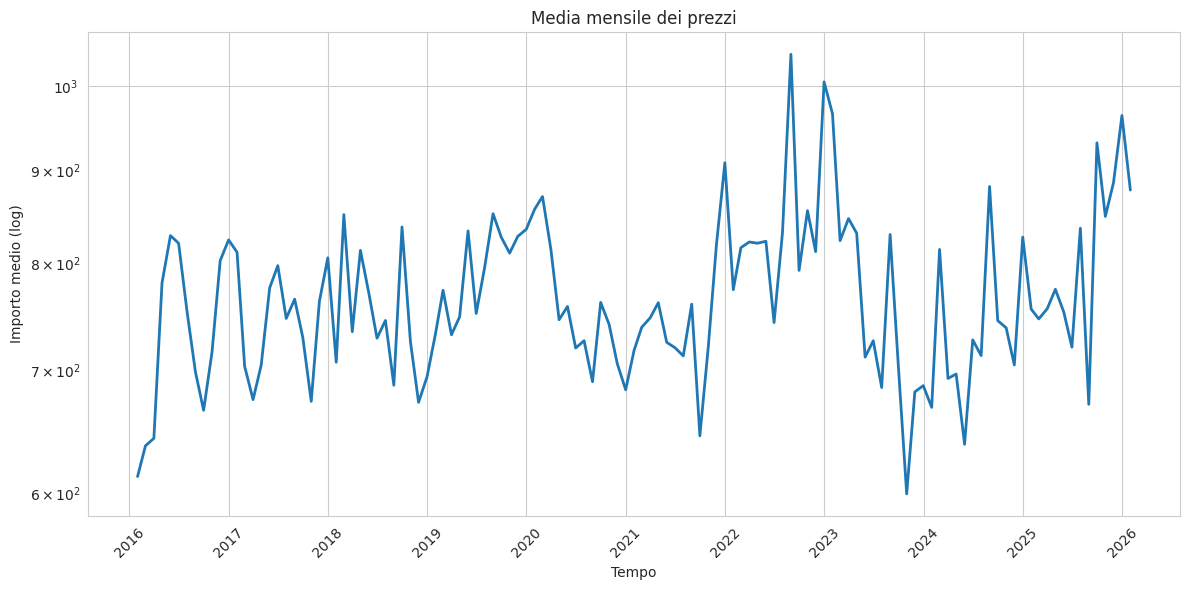

In [ ]:
# Convertiamo la colonna "importotrasp" in numerico
# Prima trasformiamo tutto in stringa
# poi sostituiamo la virgola con il punto
df["importotrasp"] = pd.to_numeric(
    df["importotrasp"].astype(str).str.replace(",", "."),
    errors="coerce" # errors="coerce" trasforma eventuali valori non validi in NaN
)

# Convertiamo la colonna "data_ordine" in formato datetime
df["data_ordine"] = pd.to_datetime(df["data_ordine"])


# Impostiamo "data_ordine" come indice del DataFrame
df = df.set_index("data_ordine")

# Calcoliamo la media mensile della colonna "importotrasp"
df_mensile = df["importotrasp"].resample("M").mean()


sns.set_style("whitegrid") # Impostazione della griglia

plt.figure(figsize=(12,6)) # Crea una figura

plt.plot(df_mensile.index, df_mensile.values, linewidth=2)

plt.yscale("log")  # Imposta scala logaritmica sull'asse y

# Titolo e etichette degli assi
plt.title("Media mensile dei prezzi")
plt.xlabel("Tempo")
plt.ylabel("Importo medio (log)")


plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


plt.xticks(rotation=45)

plt.tight_layout() # Ottimizza gli spazi nel layout

# Mostra il grafico finale
plt.show()


***Commento grafico***

Si osserva un andamento abbastanza volatile, caratterizzato da frequenti oscillazioni nel breve periodo. Questo indica una variabilità significativa dei prezzi medi mensili, probabilmente legata a fattori contingenti come domanda, costi operativi o dinamiche di mercato. Dal punto di vista del trend generale, si può notare:


*   una fase iniziale (2016–2019) relativamente stabile, con valori compresi in un intervallo medio;
*  un leggero aumento fino al 2020, seguito da una fase di fluttuazione;
* un picco significativo tra il 2022 e il 2023, che rappresenta il valore massimo della serie;
* una successiva fase di calo nel 2024, seguita da una ripresa negli anni più recenti (2025–2026).


# **Caricamento indice ISTAT**


L’**ISTAT** (Istituto Nazionale di Statistica) rappresenta l’ente pubblico di riferimento per la raccolta, produzione e diffusione di dati statistici ufficiali in Italia.

Tra le principali funzioni dell’ISTAT rientra la costruzione e pubblicazione di indicatori economici, tra cui gli indici dei prezzi, strumenti essenziali per misurare l’andamento nel tempo dei livelli di prezzo di beni e servizi. Tali indici consentono di analizzare fenomeni come l’inflazione e di valutare il potere d’acquisto della moneta.

Ciascun indice è aggiornato periodicamente per riflettere le abitudini di consumo.

Nel contesto dell’analisi di dataset storici, come nel caso delle quotazioni di trasporto merci, essi risultano fondamentali per effettuare operazioni di attualizzazione dei prezzi, eliminando l’effetto distorsivo dell’inflazione e delle variazioni macroeconomiche.

In conclusione, l’utilizzo dei dati e degli indici forniti dall’ISTAT consente di interpretare correttamente le dinamiche economiche nel tempo e di effettuare confronti significativi tra osservazioni appartenenti a periodi diversi.

In particolare, ai fini del presente studio, l’attenzione è stata posta sugli *indici ISTAT relativi ai prezzi alla produzione dei servizi B2B*, con specifico riferimento al settore **[H] Trasporto e magazzinaggio**.
Tale settore comprende diverse attività, tra cui:
* *trasporto merci su strada*
*   *trasporto marittimo e costiero*
*   *trasporto aereo*
*   *trasporto aereo di passeggeri*
* *trasporto aereo di merci*
* *magazzinaggio e custodia*
* *movimentazione merci*
* *servizi postali e attività di corriere*

Al fine di garantire coerenza nell’analisi, sono stati consultati gli archivi ufficiali dei dati, dai quali sono stati selezionati esclusivamente gli indici espressi in **base 2021**. Ciò significa che i valori dell’indice per l’anno 2021 sono stati assunti come riferimento pari a 100, e tutti gli altri valori vengono confrontati rispetto a quest'anno. La scelta di una base aggiornata permette quindi di rendere più attuale e facilmente interpretabile l’analisi dei trend dei prezzi nel settore Trasporto e magazzinaggio.

Successivamente, è stato costruito un file dedicato contenente gli indici relativi ai quattro trimestri per ciascuno degli anni considerati.

In [ ]:
url = "https://docs.google.com/spreadsheets/d/18tsZCIFS4Ls11jSksgSdVnMdVTFGRj8f/export?format=csv"

# Leggiamo il file direttamente da Google drive
indice_istat = pd.read_csv(url)

# Rinominiamo le colonne per semplicità
indice_istat = indice_istat.rename(columns={
    "TRIMESTRE": "data",
    "INDICE_ISTAT": "indice"
})

# Convertiamo la colonna 'data' in formato datetime
indice_istat["data"] = pd.to_datetime(indice_istat["data"])

# Creiamo una nuova colonna 'trimestre' basata sul periodo trimestrale
indice_istat["trimestre"] = indice_istat["data"].dt.to_period("Q")

# Impostiamo 'trimestre' come indice del DataFrame
indice_istat = indice_istat.set_index("trimestre")


/tmp/ipykernel_21234/1377213631.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  indice_istat["data"] = pd.to_datetime(indice_istat["data"])


# **Creazione funzione di attualizzazione**

*Ci viene ora chiesto di proporre ed implementare una metodologia per l'attualizzazione dei prezzi storici. Lo faremo utilizzando una funzione di attualizzazione.*

Nel contesto dell’analisi di serie storiche di prezzi, una **funzione di attualizzazione** è uno strumento che consente di rendere confrontabili valori monetari osservati in momenti temporali diversi.
In altre parole, dato un prezzo $p$ osservato al tempo $t$, la funzione
trasforma tale prezzo in un valore equivalente riferito a una data di riferimento, tenendo conto dell’effetto dell’inflazione.
Formalmente, definiamo una funzione:
$\ \ \ \ \ \ \ \ \ \ \ \ \ \ \mathbf{f : (p, t) \rightarrow p_{\text{att}}}$

dove $p_{\text{att}}$ rappresenta il prezzo attualizzato.

Nel presente lavoro, l’attualizzazione viene effettuata utilizzando un indice ISTAT dei prezzi. L'obiettivo è correggere il prezzo storico in base alla variazione dell’indice tra il tempo $t$ e il periodo corrente.

La formula adottata è:

$\ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \mathbf{p_{\text{att}} = p \cdot \frac{\text{indice}_{oggi}}{\text{indice}_t}}$

Questo approccio consente di esprimere tutti i prezzi in termini omogenei, eliminando l’effetto della variazione generale dei prezzi nel tempo.


L’utilizzo dell’indice ISTAT è giustificato da diverse ragioni:


1.   **Affidabilità istituzionale**: gli indici ISTAT sono costruiti secondo metodologie standardizzate e riconosciute a livello europeo.
2.   **Rappresentatività**: gli indici dei prezzi al consumo riflettono la variazione media dei prezzi di un paniere rappresentativo di beni e servizi.
3. **Comparabilità temporale**: la struttura degli indici è progettata proprio per confronti nel tempo, rendendoli lo strumento più appropriato per correggere valori monetari storici.


*Motivazioni teoriche:*

Il rapporto $\frac{\text{indice}_{oggi}}{\text{indice}_t}$
rappresenta il fattore cumulato di inflazione tra il tempo $t$ e oggi.
Applicare questo fattore al prezzo storico equivale a riscalarlo in termini di potere d’acquisto corrente.
Questa scelta è coerente con la teoria economica dell’inflazione, secondo cui i prezzi evolvono in modo proporzionale nel tempo.

L’adozione del periodo corrente come riferimento è giustificata da:
* **Interpretabilità**: i valori risultanti sono espressi in termini di potere d’acquisto attuale;
* **Utilità analitica**: consente confronti diretti tra prezzi storici e prezzi recenti;
* **Coerenza applicativa**: molte analisi economiche e finanziarie riportano i valori a prezzi correnti per facilitare decisioni operative.


In [ ]:
# Creiamo una nuova colonna "trimestre" partendo dalla data
df["trimestre"] = df.index.to_period("Q")

# Convertiamo la colonna 'indice' (ISTAT) in numerico
# Prima sostituiamo la virgola con il punto, poi convertiamo in numero
indice_istat['indice'] = pd.to_numeric(
    indice_istat['indice'].astype(str).str.replace(",", "."),
    errors="coerce"  # se non riesce a convertire mette NaN
)

# Uniamo il dataframe df con quello ISTAT usando il trimestre
df = df.merge(
    indice_istat[['indice']],
    left_on='trimestre',
    right_index=True,          # indice di indice_istat (che è per trimestre)
    how='left'                 # mantiene tutte le righe di df
)

# Controlliamo i formati delle colonne principali
print(df[['importotrasp', 'indice']].dtypes)

# Prendiamo l’ultimo valore disponibile dell’indice ISTAT (quello più recente)
indice_oggi = indice_istat['indice'].iloc[-1]
print("Indice oggi:", indice_oggi)

# Definiamo la funzione di attualizzazione:
def attualizza_prezzo(prezzo, indice_t, indice_oggi):
    # Se prezzo o indice sono mancanti, restituisce NaN
    if pd.notnull(prezzo) and pd.notnull(indice_t):
        return prezzo * (indice_oggi / indice_t)
    else:
        return np.nan

# Applichiamo la funzione a ogni riga del data
df['importo_attualizzato'] = df.apply(
    lambda row: attualizza_prezzo(row['importotrasp'], row['indice'], indice_oggi),
    axis=1
)

# Stampiamo alcuni risultati per controllo
df[['importotrasp', 'indice', 'importo_attualizzato']].iloc[2:10]

importotrasp    float64
indice          float64
dtype: object
Indice oggi: 115.9


,importotrasp,indice,importo_attualizzato
data_ordine,,,
2016-01-07,498.0,98.6,585.377282
2016-01-07,500.0,98.6,587.728195
2016-01-07,500.0,98.6,587.728195
2016-01-07,500.0,98.6,587.728195
2016-01-07,500.0,98.6,587.728195
2016-01-07,500.0,98.6,587.728195
2016-01-08,700.0,98.6,822.819473
2016-01-08,800.0,98.6,940.365112


# **Confronto prezzo originale vs prezzo attualizzato**

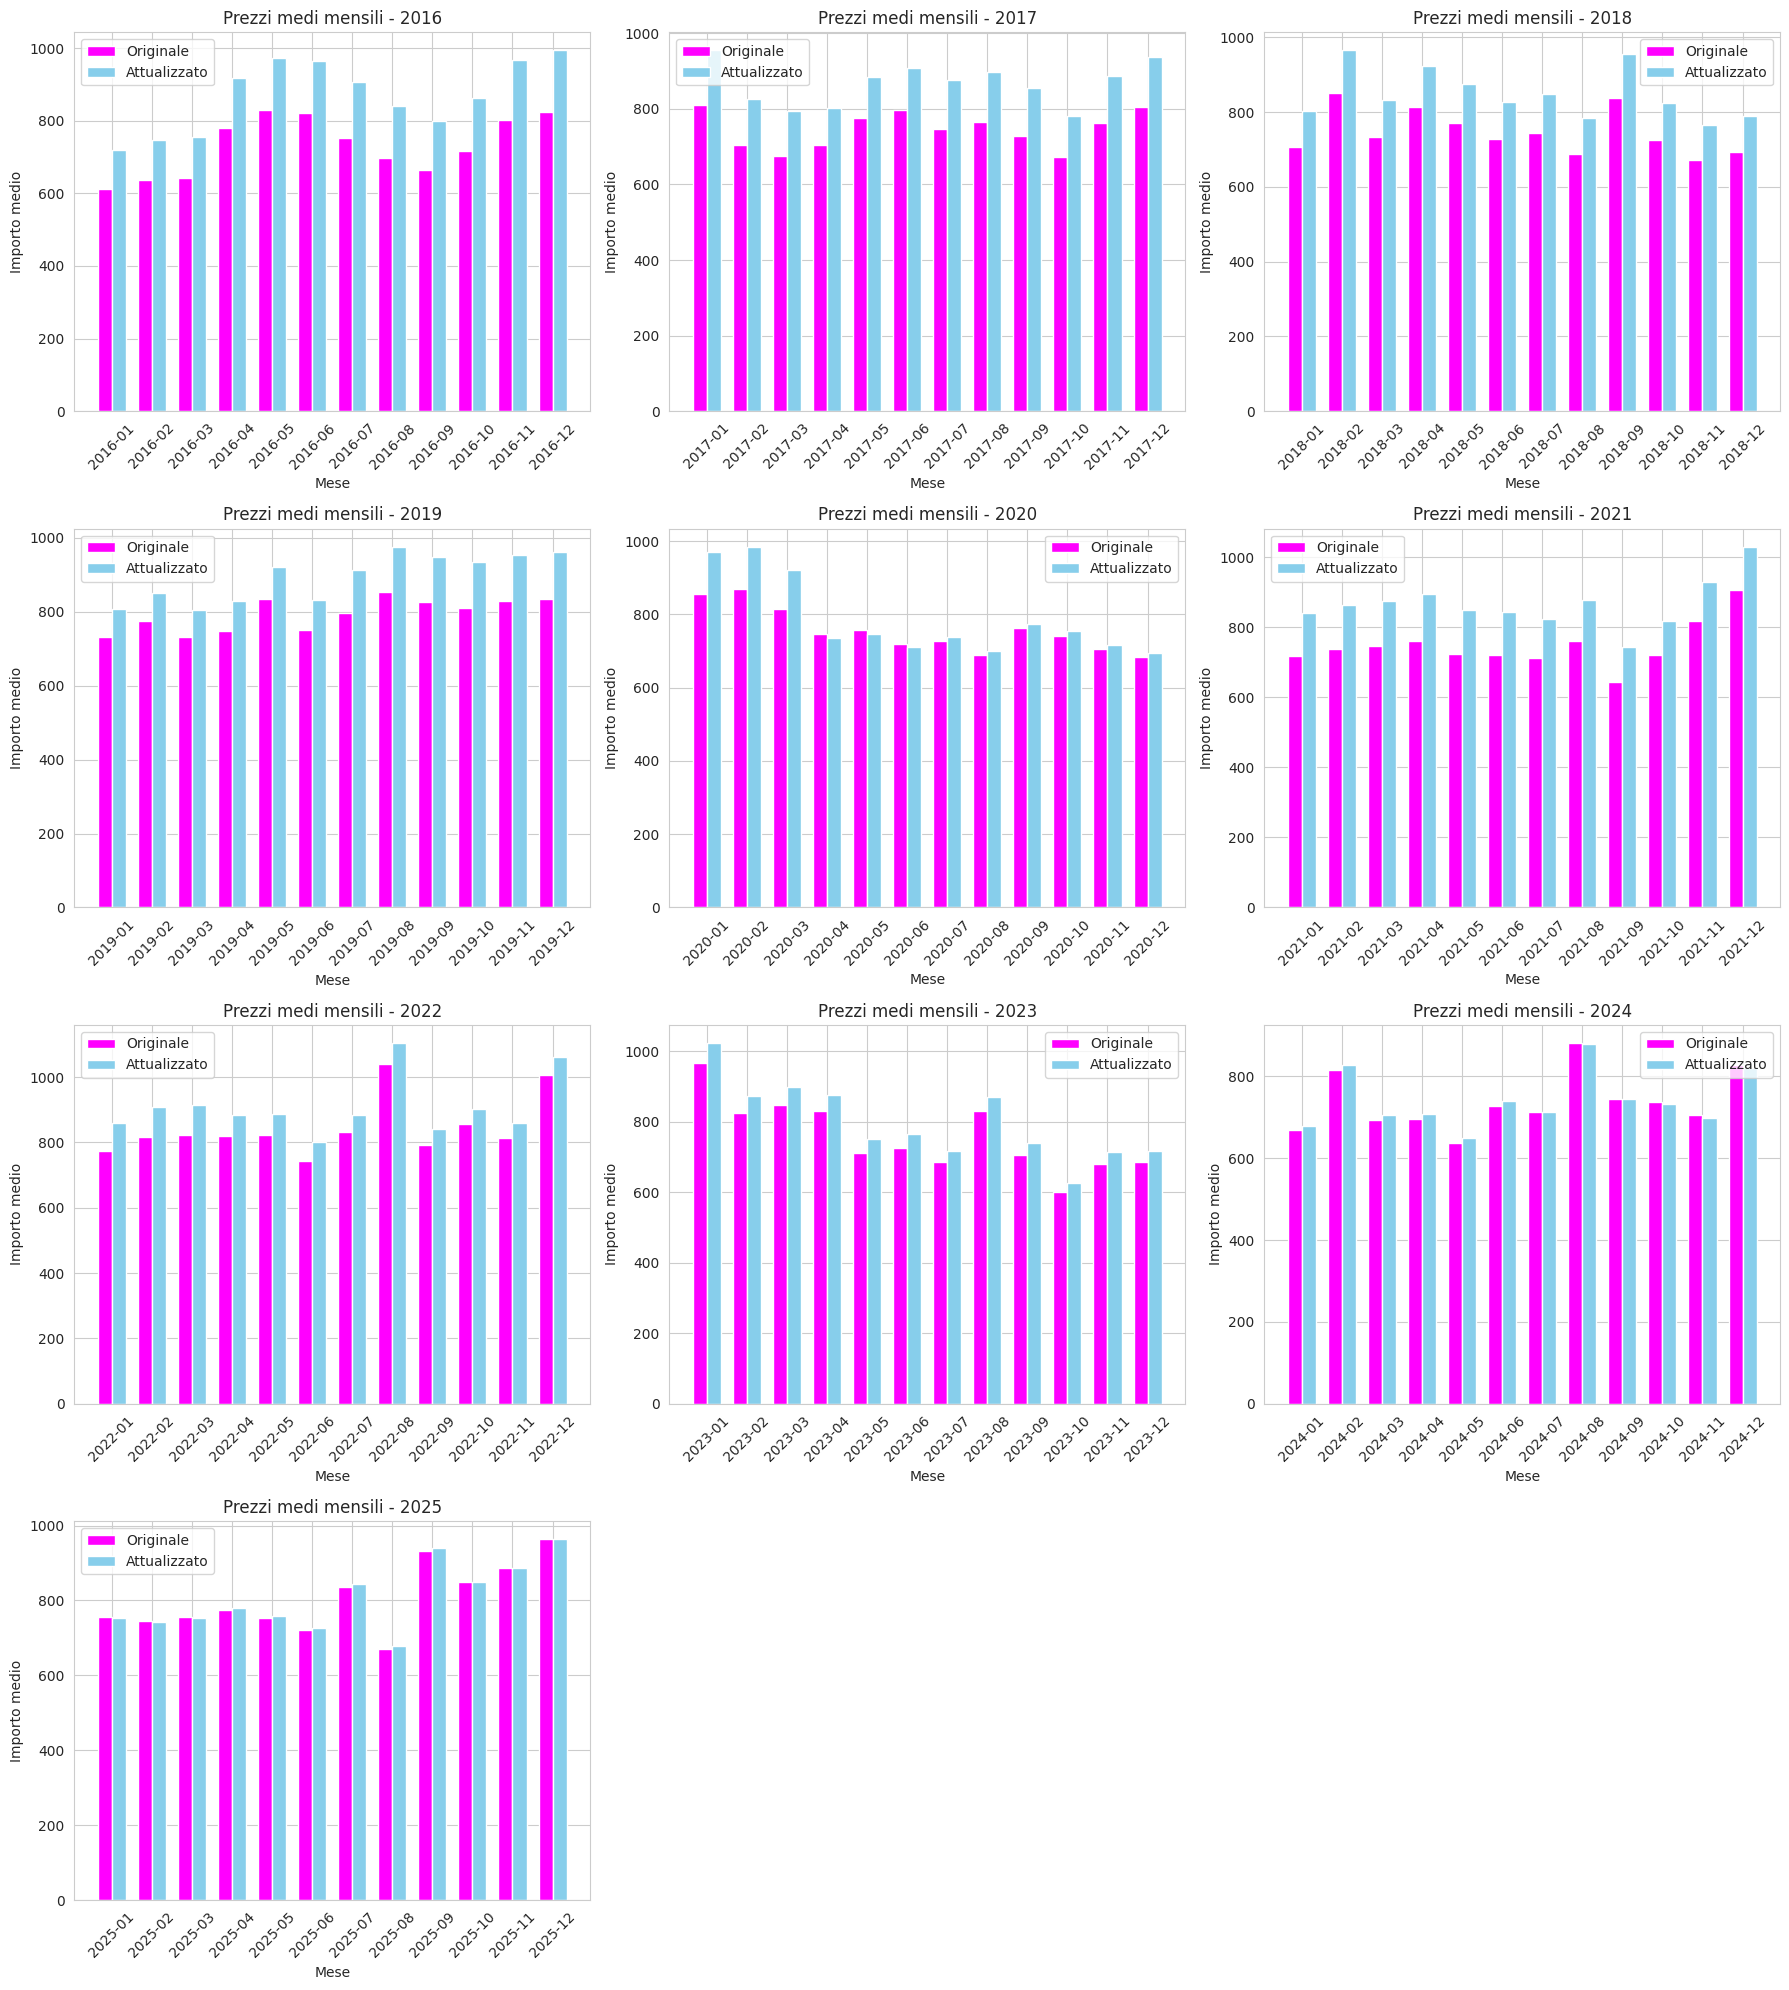

In [ ]:
# Definiamo una funzione per creare i grafici
def plot_barre_anni_grid(df, anni):

    n_anni = len(anni)  # Numero totale di anni da visualizzare
    n_col = 3  # Numero di colonne per riga (3 grafici affiancati)
    n_row = (n_anni + n_col - 1) // n_col  # Calcola quante righe servono

    # Creiamo la figura e gli assi
    fig, axes = plt.subplots(n_row, n_col, figsize=(18, 5*n_row))
    axes = axes.flatten()  # Trasforma l'array 2D degli assi in 1D per iterare facilmente

    # Ciclo su ogni anno richiesto
    for i, anno in enumerate(anni):
        ax = axes[i]  # Prende l'asse corrispondente a quest' anno

        # Filtriamo il data per selezionare solo le righe dell'anno corrente
        df_anno = df[df.index.year == anno].copy()
        if df_anno.empty:  # Se non ci sono dati per quell'anno
            ax.set_title(f"Nessun dato per {anno}")  # Mostra titolo indicativo
            ax.axis('off')  # Disattiva l'asse
            continue  # Passa al prossimo anno

        # Creiamo una colonna 'mese' basata sull'indice datetime
        df_anno['mese'] = df_anno.index.to_period('M')

        # Raggruppiamo per mese e calcoliamo la media di 'importotrasp' e 'importo_attualizzato'
        df_grouped = df_anno.groupby('mese')[['importotrasp', 'importo_attualizzato']].mean()
        if df_grouped.empty:  # Controllo aggiuntivo
            ax.set_title(f"Dati aggregati vuoti per {anno}")
            ax.axis('off')
            continue

        # Convertiamo l'indice Period in stringa "YYYY-MM" per le etichette dei mesi
        df_grouped.index = df_grouped.index.strftime('%Y-%m')

        x = np.arange(len(df_grouped))  # Posizioni asse X
        width = 0.35  # Larghezza delle barre

        # Disegna le barre:
        ax.bar(x - width/2, df_grouped['importotrasp'], width, label='Originale', color='magenta')
        ax.bar(x + width/2, df_grouped['importo_attualizzato'], width, label='Attualizzato', color='skyblue')

        # Etichette asse X
        ax.set_xticks(x)
        ax.set_xticklabels(df_grouped.index, rotation=45)


        ax.set_title(f"Prezzi medi mensili - {anno}", fontsize=12)
        ax.set_xlabel("Mese")
        ax.set_ylabel("Importo medio")
        ax.legend()

    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


# Chiamata alla funzione
plot_barre_anni_grid(df, [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])

/tmp/ipykernel_21234/3905365677.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_mensile = df[['importotrasp', 'importo_attualizzato']].resample("M").mean()


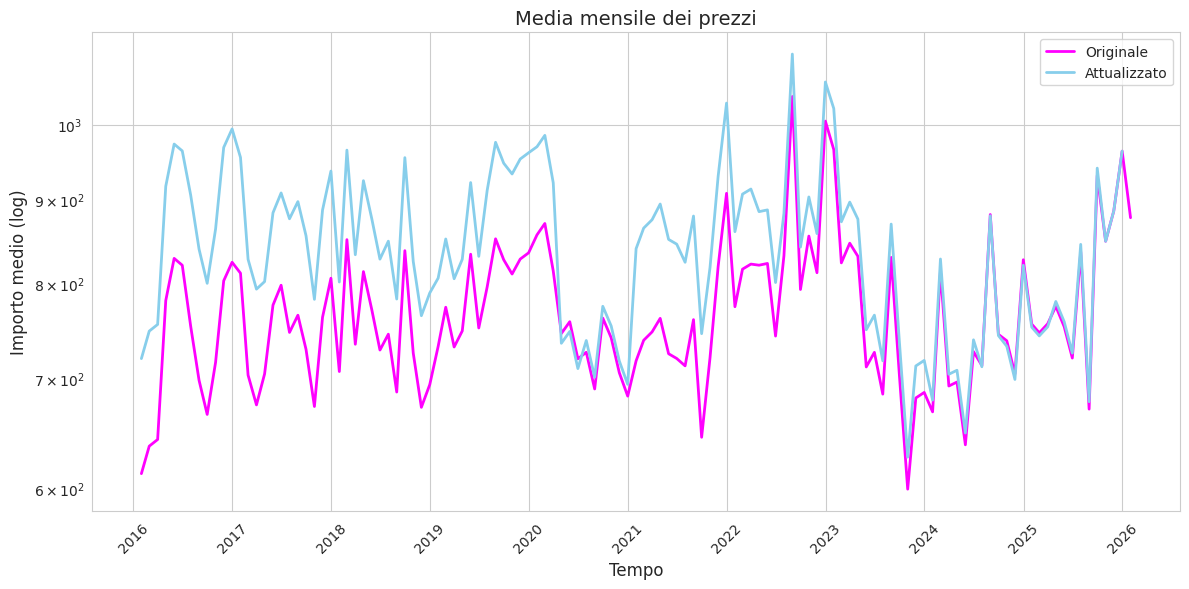

In [ ]:
# Controlliamo che 'importo_attualizzato' sia numerico
df['importo_attualizzato'] = pd.to_numeric(df['importo_attualizzato'], errors='coerce')

# Calcoliamo la media mensile sia per importo originale che attualizzato
df_mensile = df[['importotrasp', 'importo_attualizzato']].resample("M").mean()

sns.set_style("whitegrid")

plt.figure(figsize=(12,6)) # Crea la figura

# Disegniamo le linee
plt.plot(df_mensile.index, df_mensile['importotrasp'], linewidth=2, label='Originale', color='magenta')
plt.plot(df_mensile.index, df_mensile['importo_attualizzato'], linewidth=2, label='Attualizzato', color='skyblue')

plt.yscale("log") # Scala logaritmica per l'asse Y

plt.title("Media mensile dei prezzi", fontsize=14)
plt.xlabel("Tempo", fontsize=12)
plt.ylabel("Importo medio (log)", fontsize=12)

# Formattazione asse X per anno
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show() # Mostra il grafico

***Commento grafico***


Il grafico analizza l’andamento della media mensile dei prezzi nel periodo considerato, confrontando i valori originali con quelli attualizzati mediante indice ISTAT, al fine di tenere conto dell’effetto dell’inflazione nel tempo.

Dal confronto tra le due serie emerge chiaramente che l’attualizzazione non modifica la dinamica temporale dei dati, bensì ne altera il livello. Le due curve risultano infatti sostanzialmente parallele, indicando che le variazioni dei prezzi vengono preservate anche dopo la trasformazione. Tuttavia, i valori attualizzati si collocano sistematicamente al di sopra di quelli originali, soprattutto nei periodi più lontani nel tempo. Questo fenomeno riflette la perdita del potere d’acquisto della moneta: i prezzi storici, se espressi a valori correnti, risultano più elevati proprio per compensare l’inflazione cumulata.

Nel complesso, l’analisi conferma l’importanza dell’attualizzazione nelle valutazioni economiche di lungo periodo. Il confronto tra valori originali e reali permette infatti di distinguere tra variazioni effettive dei prezzi e semplici effetti dovuti all’inflazione, offrendo una lettura più accurata dell’evoluzione economica del fenomeno osservato.


# **Incertezza del modello**

*Ci viene chiesto di quantificare l'incertezza intrinseca del processo di attualizzazione proposto e di stimare quanto il metodo scelto introduce variabilità o errore sistematico nei prezzi trasformati.*

Si parte dall'analizzare la variabilità che misura il grado di dispersione dei dati rispetto al valore medio e consente di valutare quanto un processo (come l’attualizzazione) introduca o amplifichi le differenze tra osservazioni. Si misura spesso con la **deviazione standard**
\begin{equation*}
σ=\sqrt{\frac{1}{n}∑_{i=1}^n(x_i-μ)^2}
\end{equation*}

dove $x_i$ sono i singoli valori, $\mu$ è la media ed $n$ è il numero di dati.
Essa è una misura statistica che ci indica quanto i dati sono dispersi rispetto alla media.

Nel nostro caso visto che abbiamo usato la formula
\begin{equation*}
prezzo\cdot \frac{indice_{oggi}}{indice_t}
\end{equation*}

se l’indice presenta forti variazioni nel tempo, la variabilità dei valori attualizzati tende ad aumentare; al contrario, se l’indice è stabile, la variabilità cambia poco.

In particolare facendo il rapporto tra la deviazione standard del prezzo attualizzato e di quello originale si ha che:

* se è maggiore di 1, si ha un’amplificazione della variabilità;
* se è minore di 1, la variabilità si riduce;
* se è circa uguale a 1, l’effetto è sostanzialmente neutro.

In [ ]:
std_originale = df['importotrasp'].std() # Calcolo deviazione standard del prezzo originale
std_attualizzato = df['importo_attualizzato'].std() # Calcolo deviazione standard del prezzo attualizzato

print("Deviazione standard originale:", std_originale)
print("Deviazione standard attualizzata:", std_attualizzato)
print("Rapporto:", std_attualizzato / std_originale) # Confronto delle due variabilità

Deviazione standard originale: 649.5217089354516
Deviazione standard attualizzata: 701.9744056058723
Rapporto: 1.0807558792090095


***Commento dei risultati***

In termini intuitivi, l’attualizzazione comporta che i prezzi meno recenti vengano rivalutati maggiormente rispetto a quelli recenti, determinando un aumento della distanza tra i valori e quindi della variabilità.

L’analisi della deviazione standard evidenzia, infatti, un incremento della variabilità pari a circa l’8% dopo l’attualizzazione. Questo risultato indica che il metodo non è neutrale dal punto di vista statistico cioè non lascia i dati invariati, ma li modifica in modo sistematico.
Introduce una moderata amplificazione della dispersione dei prezzi, legata alla dinamica temporale dell’indice utilizzato.

# **Coefficiente di variazione**

Il coefficiente di variazione è definito come
\begin{equation*}
CV=\frac{σ}{μ}
\end{equation*}

dove $σ$ è la deviazione standard mentre μ è la media. In altre parole misura quanta variabilità c'è rispetto al livello medio dei dati.

In [ ]:
# Calcoliamo CV sia per i prezzi originali che per quelli attualizzati
cv_originale = std_originale / df['importotrasp'].mean()
cv_attualizzato = std_attualizzato / df['importo_attualizzato'].mean()

print("CV originale:", cv_originale)
print("CV attualizzato:", cv_attualizzato)

CV originale: 0.8476192154078969
CV attualizzato: 0.8432187808793842


***Commento dei risultati***

Dai risultati ottenuti si osserva che il **coefficiente di variazione**, dopo l'attualizzazione,  subisce una lieve diminuzione (da 0,848 a 0,843). Questo significa che l’aumento della dispersione è accompagnato da un aumento ancora maggiore della media, rendendo la variabilità proporzionale leggermente più contenuta.
In altre parole, anche se i valori attualizzati sono più distanti tra loro in termini assoluti, nel complesso risultano quasi altrettanto omogenei rispetto alla loro dimensione media. Si può quindi concludere che l’attualizzazione non ha introdotto una reale instabilità nei dati, ma ha mantenuto una variabilità relativa sostanzialmente invariata, con un leggero miglioramento in termini di uniformità.

# **Differenza media (BIAS)**

Viene adesso calcolata la differenza media tra i prezzi attualizzati e quelli originali.

* Se bias > 0 → il metodo tende a sovrastimare i prezzi
* Se bias < 0 → il metodo tende a sottostimare i prezzi
* Se bias ≈ 0 → il metodo è neutro

In [ ]:
# Calcoliamo la differenza media
bias = (df['importo_attualizzato'] - df['importotrasp']).mean()
print("Bias medio:", bias)

Bias medio: 66.95549520659891


***Commento dei risultati***

L’analisi del bias medio mostra che il processo di attualizzazione introduce un incremento sistematico dei prezzi pari a circa 67 unità.

Tale effetto è spiegabile principalmente con la dinamica dell’indice ISTAT: essendo generalmente crescente nel tempo, i prezzi più datati vengono rivalutati tramite un fattore maggiore di 1, determinando così un aumento medio dei valori. Inoltre, l’entità del bias dipende anche dalla distribuzione temporale dei dati: una maggiore presenza di prezzi risalenti nel tempo comporta un incremento più marcato.

# **Analisi relativa**



In [ ]:
# Calcoliamo l'errore relativo
df['errore_relativo'] = (
    (df['importo_attualizzato'] - df['importotrasp']) / df['importotrasp']
)

# Stampiamo la statistica descrittiva dell'errore relativo
print(df['errore_relativo'].describe())

count    41691.000000
mean         0.087366
std          0.065849
min         -0.013617
25%          0.016667
50%          0.100665
75%          0.145257
max          0.206035
Name: errore_relativo, dtype: float64


**Commento dei risultati**

| Statistica | Valore  | Significato                                                                              |
| ---------- | ------- | ---------------------------------------------------------------------------------------- |
| count      | 41691   | Numero totale di prezzi considerati                                                      |
| mean       | 0.0874  | In media, i prezzi aumentano dell’**8.7%**                                               |
| std        | 0.0658  | Dispersione dell’errore relativo: alcune osservazioni aumentano molto di più, altre meno |
| min        | -0.0136 | Il prezzo più “attualizzato” è **leggermente diminuito** (-1.36%)                        |
| 25%        | 0.0167  | 25% dei prezzi sono aumentati **al massimo del 1.67%**                                   |
| 50%        | 0.1007  | Mediana: metà dei prezzi aumentano meno del 10%, metà di più                             |
| 75%        | 0.1453  | 75% dei prezzi aumentano meno del 14.5%                                                  |
| max        | 0.2060  | L’aumento massimo osservato è circa **20.6%**                                            |


L’analisi dell’errore relativo evidenzia che, dopo l’attualizzazione, i prezzi aumentano in media dell’8,7%, confermando la presenza di un bias positivo già osservato.

La variabilità dell’effetto è contenuta: la deviazione standard relativa è pari al 6,6%, il che indica che l’impatto dell’attualizzazione non è uniforme, ma differisce tra le osservazioni. In particolare, le variazioni spaziano da circa -1,3% fino a +20,6%, segnalando che alcuni prezzi subiscono modifiche minime mentre altri aumentano in modo più marcato.

La mediana pari al 10%, superiore alla media, suggerisce inoltre una distribuzione leggermente asimmetrica, con una prevalenza di aumenti più consistenti in una parte delle osservazioni.

Nel complesso, il metodo introduce un aumento moderato dei prezzi, mantenendo però relativamente stabile la loro struttura complessiva.

# **Bootstrap**

Il bootstrap è una tecnica statistica di ricampionamento che permette di stimare la distribuzione di una statistica (ad esempio una media o una differenza) senza fare ipotesi forti sulla distribuzione dei dati.

L’idea di base è semplice:

* si parte da un dataset osservato
* si creano tanti nuovi campioni estraendo casualmente con reinserimento
* si calcola la statistica di interesse su ciascun campione
* si analizza la distribuzione dei risultati ottenuti

In [ ]:
# Creaiamo la funzione per usare il bootstrap
def bootstrap_attualizzazione(df, n=1000):
    # Parametri:
    # df: data con colonne 'importotrasp' e 'importo_attualizzato'
    # n: numero di campioni bootstrap da generare (default 1000)
    # Output:
    # array di differenze medie (media attualizzata - media originale) per ogni campione

    risultati = []  # Lista per salvare le differenze medie dei campioni

    for _ in range(n):

        sample = df.sample(frac=1, replace=True) # Creazione campione casuale della stessa dimensione

        media_orig = sample['importotrasp'].mean()
        media_att = sample['importo_attualizzato'].mean()

        risultati.append(media_att - media_orig) # Salviamo la differenza media

    return np.array(risultati) # restituisce la lista in array numpy

# Chiamata della funzione sul data frame
res = bootstrap_attualizzazione(df)

# Calcoliamo la media della distribuzione di bootstrap → stima del bias medio
print("Media errore:", res.mean())

# Calcoliamo la deviazione standard della distribuzione di bootstrap → misura dell'incertezza
print("Std errore:", res.std())


Media errore: 66.19891033559057
Std errore: 0.5366519618428527


La **media dell’errore** (~66.2) conferma il bias medio stimato in precedenza  (≈66.96).
Questo indica che, in media, i prezzi attualizzati risultano circa 66 unità più elevati rispetto ai prezzi originali.

La **deviazione standard** dell’errore (~0.54) misura l’incertezza associata alla stima della media dovuta alla variabilità del campione. Il valore molto contenuto suggerisce che la stima è estremamente stabile.

In altre parole, ripetendo il bootstrap, la differenza media tra prezzi attualizzati e originali varia in misura minima.

L’analisi bootstrap conferma la presenza di un bias medio significativo introdotto dall’attualizzazione: la differenza tra prezzi attualizzati e originali è pari a circa 66 unità.

L’errore standard molto ridotto (0.54) indica che questa stima è robusta e poco sensibile alla variabilità campionaria, rafforzando l’affidabilità dei risultati ottenuti.

# **Intervallo di confidenza**

L'intervallo di confidenza è uno strumento statistico che permette di stimare un intervallo di valori plausibili per un parametro incognito.

Esso viene costruito utilizzando i percentili della distribuzione empirica ottenuta tramite ricampionamento. In particolare, è stato considerato un intervallo di confidenza al 95%, determinato dal 2.5° e dal 97.5° percentile della distribuzione.
Questa scelta rappresenta un buon equilibrio tra precisione e affidabilità, in quanto l’intervallo non risulta né troppo stretto (e quindi instabile), né troppo ampio (e quindi poco informativo).

In [ ]:
# Intervallo di confidenza al 95%
lower = np.percentile(res, 2.5)
upper = np.percentile(res, 97.5)

print("Intervallo di confidenza 95%:", lower, upper)


Intervallo di confidenza 95%: 65.12321407350588 67.26287996498472


# **Rappresentazione grafica**

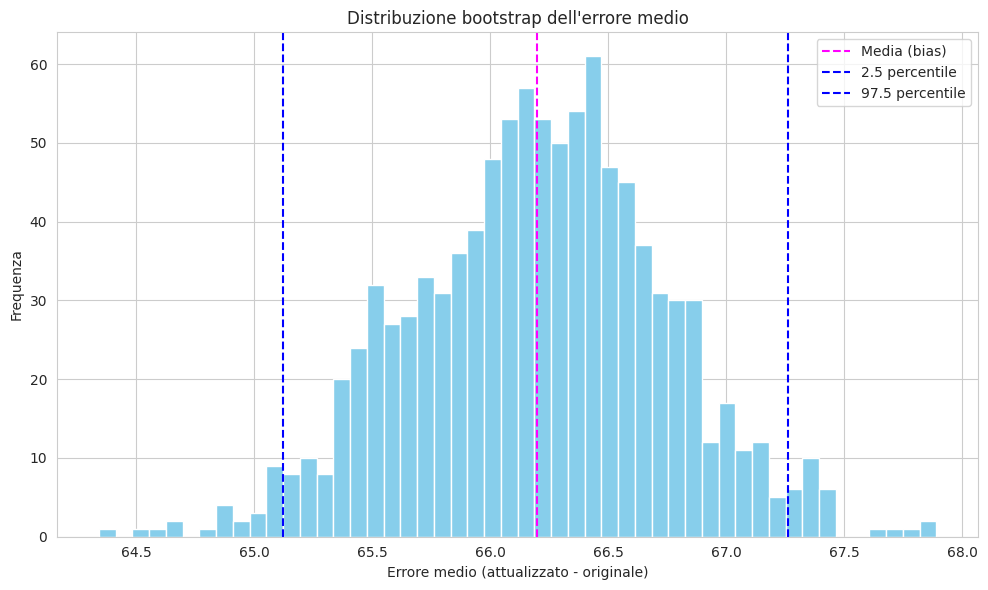

In [ ]:
# Media e deviazione standard
media_boot = res.mean()
std_boot = res.std()

# Creazione plot
plt.figure(figsize=(10,6))

# Istogramma
plt.hist(res, bins=50,color='skyblue')

# Linea della media
plt.axvline(media_boot, linestyle='--', label='Media (bias)',color='magenta')

# Linee intervallo di confidenza
plt.axvline(lower, linestyle='--', label='2.5 percentile', color='blue')
plt.axvline(upper, linestyle='--', label='97.5 percentile',color='blue')

# Etichette
plt.title("Distribuzione bootstrap dell'errore medio")
plt.xlabel("Errore medio (attualizzato - originale)")
plt.ylabel("Frequenza")

plt.legend()
plt.tight_layout()
plt.show()

***Commento dei risultati***

Il grafico rappresenta la distribuzione bootstrap dell’errore medio tra i prezzi attualizzati e quelli originali.

La linea verticale tratteggiata al centro indica la media della distribuzione, che rappresenta una stima del bias del metodo. Il fatto che questa sia diversa da zero evidenzia la presenza di un errore sistematico introdotto dal processo di attualizzazione.

La forma approssimativamente simmetrica della distribuzione suggerisce che l’errore sia relativamente stabile, mentre la sua ampiezza riflette il livello di variabilità introdotto dal processo di attualizzazione.

In conclusione, il metodo presenta sia una componente di errore sistematico sia una componente di variabilità, che possono essere quantificate rispettivamente dalla media e dalla deviazione standard della distribuzione bootstrap.

# **Limiti del metodo**

*Ci viene chiesto di discutere sui limiti del metodo e di proporre eventuali strategie per ridurre l'incertezza dell'attualizzazione.*

L'attuale modello di attualizzazione, sebbene tecnicamente solido e basato su un indice settoriale specifico, presenta dei margini di incertezza che sono stati evidenziati chiaramente tramite la distribuzione Bootstrap. Il fatto che l'errore non sia nullo indica che l'indice ISTAT, da solo, non riesce a spiegare completamente la variazione dei prezzi nel tempo. I principali limiti sono:

1. **Limite della Risoluzione Temporale** (Trimestrale vs Mensile) ->
Uno dei problemi principali risiede nella frequenza dell'indice. ISTAT pubblica l'indice settoriale su base trimestrale, mentre i prezzi dei trasporti nel dataset variano giorno per giorno. Questo comporta:
      * *Smoothing Bias*: L'indice trimestrale opera una media che "appiattisce" la realtà.
      * *Mancata sincronia*: L'applicazione di un unico coefficiente a tutte le transazioni di un intero trimestre ignora le dinamiche di mercato infra-mensili, aumentando la varianza del prezzo attualizzato.
2. **Variabili non considerate** -> Il prezzo del trasporto è influenzato da variabili specifiche non incluse nel calcolo. Ad esempio:
     * *Prezzo Carburante*: prezzo_carb è la variabile più instabile. L'indice ISTAT include il carburante, ma non riflette i supplementi del carburante applicati in tempo reale.
     * *Tipo Carico*: il dataset aggrega tipologie di trasporto diverse. Un indice generale non può distinguere tra un trasporto a carico completo e uno parziale.
     * *Peso veicolo*: il peso influisce in modo non lineare sul consumo di carburante e sui costi di manutenzione. Le variazioni nella tipologia di carico possono generare fluttuazioni di prezzo che l'indice ISTAT non è in grado di neutralizzare.
     * *Km_tratta*: la variabile che incide in modo più complesso, perché non influisce sul prezzo in maniera direttamente proporzionale (lineare), creando quello che in economia dei trasporti si chiama "degressività delle tariffe".

# **STRATEGIA 1: Indice ISTAT (mensile)**

Considerando che gli indici ISTAT sono disponibili su base trimestrale, si procede a un’interpolazione lineare al fine di ottenere una stima degli indici su base mensile.

Dopodiché si ricalcolano i prezzi attualizzati.


In [ ]:
# Caricamento indici ISTAT
url = "https://docs.google.com/spreadsheets/d/18tsZCIFS4Ls11jSksgSdVnMdVTFGRj8f/export?format=csv"
indice_istat = pd.read_csv(url)

indice_istat = indice_istat.rename(columns={
    "TRIMESTRE": "data",
    "INDICE_ISTAT": "indice"
})

# Sostituiamo la virgola con il punto e convertiamo in numerico
indice_istat['indice'] = pd.to_numeric(
    indice_istat['indice'].astype(str).str.replace(",", "."),
    errors="coerce"
)

# Convertiamo in formato datatime
indice_istat['data'] = pd.to_datetime(indice_istat['data'], errors='coerce')

indice_istat = indice_istat.set_index('data').sort_index() # Imposta indice datetime

# Creiamo tutte le date mensili fino a dicembre 2025
date_complete = pd.date_range(
    start=indice_istat.index.min(),
    end="2025-12-01",
    freq="MS"
)

indice_istat_mensile = indice_istat.reindex(date_complete) # Aggiunge mesi mancanti

# Interpolazione e riempimento ultimi valori
indice_istat_mensile['indice'] = (
    indice_istat_mensile['indice']
    .interpolate()
    .ffill()
)

# Stampa indici mensili
print(indice_istat_mensile.head(5))

# Ricalcoliamo prezzi attualizzati:

# Creiamo colonna mese
df["mese"] = df.index.to_period("M")

# Prepariamo ISTAT mensile
indice_istat_mensile["mese"] = indice_istat_mensile.index.to_period("M")
indice_istat_mensile = indice_istat_mensile.set_index("mese")

# Rimuoviamo eventuale vecchia colonna indice
df = df.drop(columns=['indice'], errors='ignore')

# Uniamo il dataframe df con quello ISTAT usando il mese
df['importo_attualizzato_old'] = df['importo_attualizzato']
df = df.merge(
    indice_istat_mensile[['indice']],
    left_on='mese',
    right_index=True,
    how='left'
)

# Stampa di controllo
#print(df[['importotrasp', 'indice']].dtypes)
#print("NaN indice:", df['indice'].isna().sum())

# Stampiamo indice attuale
indice_oggi = indice_istat_mensile['indice'].iloc[-1]
print("Indice oggi:", indice_oggi)

# Definiamo la nuova funzione di attualizzazione
def attualizza_prezzo(prezzo, indice_t, indice_oggi):
    if pd.notnull(prezzo) and pd.notnull(indice_t):
        return prezzo * (indice_oggi / indice_t)
    else:
        return np.nan

# Aggiungiamo la colonna dei nuovi prezzi attualizzati
df['importo_attualizzato_new'] = df.apply(
    lambda row: attualizza_prezzo(row['importotrasp'], row['indice'], indice_oggi),
    axis=1
)

# Stampa di controllo
print(df[['importotrasp', 'indice', 'importo_attualizzato_new']].iloc[2:10])

/tmp/ipykernel_21234/2321052850.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  indice_istat['data'] = pd.to_datetime(indice_istat['data'], errors='coerce')


               indice
2016-01-01  98.600000
2016-02-01  98.633333
2016-03-01  98.666667
2016-04-01  98.700000
2016-05-01  97.933333
Indice oggi: 115.9
             importotrasp  indice  importo_attualizzato_new
data_ordine                                                
2016-01-07          498.0    98.6                585.377282
2016-01-07          500.0    98.6                587.728195
2016-01-07          500.0    98.6                587.728195
2016-01-07          500.0    98.6                587.728195
2016-01-07          500.0    98.6                587.728195
2016-01-07          500.0    98.6                587.728195
2016-01-08          700.0    98.6                822.819473
2016-01-08          800.0    98.6                940.365112


**Confronto grafico**

/tmp/ipykernel_21234/2863789030.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_mensile = df[['importotrasp', 'importo_attualizzato_old', 'importo_attualizzato_new']].resample("M").mean()


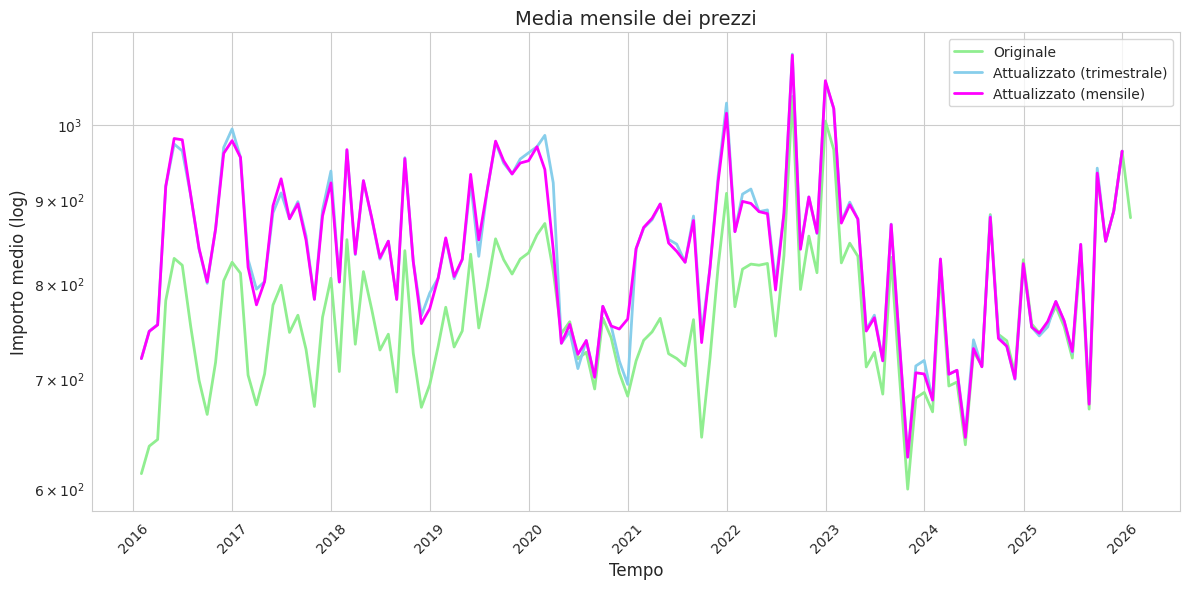

In [ ]:
# Controlliamo che le colonne siano numeriche
df['importo_attualizzato_old'] = pd.to_numeric(df['importo_attualizzato_old'], errors='coerce')
df['importo_attualizzato_new'] = pd.to_numeric(df['importo_attualizzato_new'], errors='coerce')

# Calcoliamo la media mensile
df_mensile = df[['importotrasp', 'importo_attualizzato_old', 'importo_attualizzato_new']].resample("M").mean()

sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

# Prezzo originale
plt.plot(df_mensile.index, df_mensile['importotrasp'],
         linewidth=2, label='Originale', color='lightgreen')

# Prezzo attualizzato
plt.plot(df_mensile.index, df_mensile['importo_attualizzato_old'],
         linewidth=2, label='Attualizzato (trimestrale)', color='skyblue')

# Prezzo attualizzato nuovo
plt.plot(df_mensile.index, df_mensile['importo_attualizzato_new'],
         linewidth=2, label='Attualizzato (mensile)', color='magenta')

# Scala log
plt.yscale("log")

# Titoli
plt.title("Media mensile dei prezzi", fontsize=14)
plt.xlabel("Tempo", fontsize=12)
plt.ylabel("Importo medio (log)", fontsize=12)

# Asse X
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

***Commento grafico***

L’attualizzazione mensile (linea magenta) mostra un andamento più fluido e reattivo rispetto a quella trimestrale (linea azzurra), poiché utilizza un indice ISTAT interpolato mese per mese. Questo consente di cogliere variazioni più puntuali nel tempo, mentre l’approccio trimestrale, applicando lo stesso indice per tre mesi consecutivi, risulta più stabile ma meno sensibile alle oscillazioni di breve periodo.

# **Calcolo dell'incertezza**

In [ ]:
std_originale = df['importotrasp'].std() # Calcolo deviazione standard del prezzo originale
std_attualizzato_new = df['importo_attualizzato_new'].std() # Calcolo deviazione standard del prezzo nuovo attualizzato

print("Deviazione standard originale:", std_originale)
print("Deviazione standard attualizzata nuova:", std_attualizzato_new)
print("Rapporto:", std_attualizzato_new / std_originale) # Confronto delle due variabilità


Deviazione standard originale: 649.5217089354516
Deviazione standard attualizzata nuova: 700.8302694123176
Rapporto: 1.0789943735074836


In [ ]:
# Calcoliamo CV sia per i prezzi originali che per quelli nuovi attualizzati
cv_originale = std_originale / df['importotrasp'].mean()
cv_attualizzato_new = std_attualizzato_new / df['importo_attualizzato_new'].mean()

print("CV originale:", cv_originale)
print("CV attualizzato nuovo:", cv_attualizzato_new)


CV originale: 0.8476192154078969
CV attualizzato nuovo: 0.8430121360954995


In [ ]:
# Calcoliamo la differenza media
bias_new = (df['importo_attualizzato_new'] - df['importotrasp']).mean()
print("Bias medio:", bias_new)

Bias medio: 65.80236151976598


In [ ]:
# Calcoliamo l'errore relativo
df['errore_relativo_new'] = (
    (df['importo_attualizzato_new'] - df['importotrasp']) / df['importotrasp']
)

# Stampiamo la statistica descrittiva dell'errore relativo
print(df['errore_relativo_new'].describe())


count    41691.000000
mean         0.086128
std          0.063820
min         -0.013617
25%          0.016667
50%          0.078809
75%          0.143374
max          0.206035
Name: errore_relativo_new, dtype: float64


Media errore: 65.07090772761022
Std errore: 0.557117523425636
Intervallo di confidenza 95%: 63.96473571968984 66.11913229899491


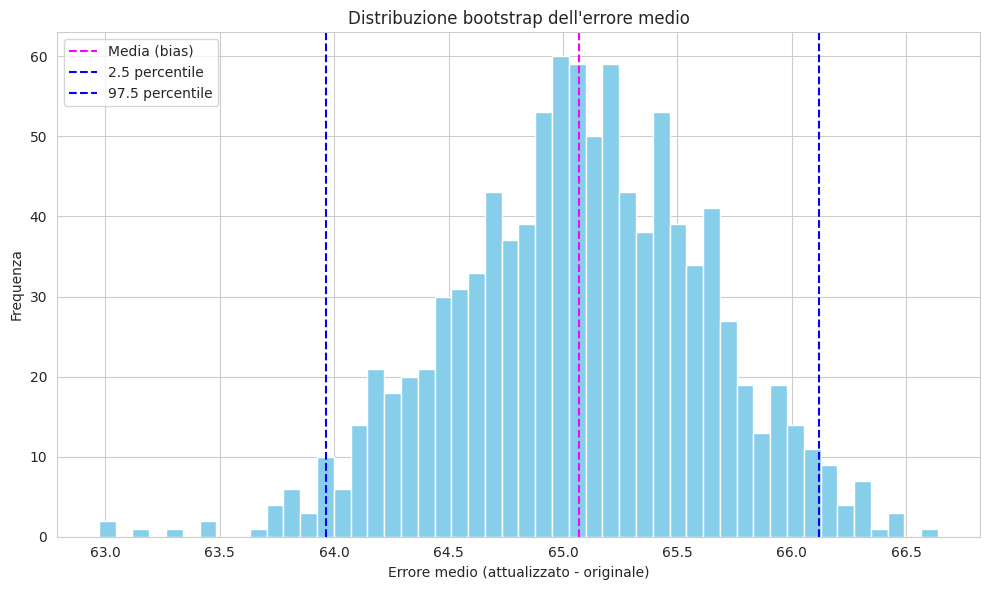

In [ ]:
# Definiamo la nuova funzione per usare il bootstrap
def bootstrap_attualizzazione_new(df, n=1000):
    # Parametri:
    # df: data con colonne 'importotrasp' e 'importo_attualizzato_new'
    # n: numero di campioni bootstrap da generare (default 1000)
    # Output:
    # array di differenze medie (media attualizzata - media originale) per ogni campione

    risultati_new = []  # Lista per salvare le differenze medie dei campioni

    for _ in range(n):

        sample_new = df.sample(frac=1, replace=True) # Creazione campione casuale della stessa dimensione

        media_orig_new = sample_new['importotrasp'].mean()
        media_att_new = sample_new['importo_attualizzato_new'].mean()

        risultati_new.append(media_att_new - media_orig_new) # Salviamo la differenza media

    return np.array(risultati_new) # restituisce la lista in array numpy


res_new = bootstrap_attualizzazione_new(df) # Chiamata della funzione sul data frame

# Calcoliamo la media della distribuzione di bootstrap → stima del bias medio
print("Media errore:", res_new.mean())

# Calcoliamo la deviazione standard della distribuzione di bootstrap → misura dell'incertezza
print("Std errore:", res_new.std())


# Definiamo l'intervallo di confidenza al 95%
lower_new = np.percentile(res_new, 2.5)
upper_new = np.percentile(res_new, 97.5)

print("Intervallo di confidenza 95%:", lower_new, upper_new)

# Media e deviazione standard
media_boot_new = res_new.mean()
std_boot_new = res_new.std()


# Creazione plot
plt.figure(figsize=(10,6))

# Istogramma
plt.hist(res_new, bins=50,color='skyblue')

# Linea della media
plt.axvline(media_boot_new, linestyle='--', label='Media (bias)',color='magenta')

# Linee intervallo di confidenza
plt.axvline(lower_new, linestyle='--', label='2.5 percentile', color='blue')
plt.axvline(upper_new, linestyle='--', label='97.5 percentile',color='blue')

# Etichette
plt.title("Distribuzione bootstrap dell'errore medio")
plt.xlabel("Errore medio (attualizzato - originale)")
plt.ylabel("Frequenza")

plt.legend()
plt.tight_layout()
plt.show()

***Confronto dei risultati***

Il metodo aggiornato produce un miglioramento sistematico, ma contenuto delle performance. In particolare, si osserva una riduzione del bias medio (−1.7%) e della dispersione dell’errore relativo (−3.1%). L’aspetto più rilevante è la significativa diminuzione della mediana dell’errore relativo (−21.7%), che indica un miglioramento concreto nei casi maggiormente osservati e una minore incidenza di errori elevati. Tuttavia, le misure globali di variabilità (deviazione standard e coefficiente di variazione) rimangono sostanzialmente invariate, suggerendo che il nuovo metodo rappresenta un affinamento incrementale senza modificare la struttura statistica complessiva del fenomeno.

# **STRATEGIA 2: INCLUSIONE ALTRE VARIABILI**

Per risolvere i problemi derivanti dalla presenza di variabili non considerate, viene adottato un approccio multifattoriale in cui il prezzo viene modellato come funzione delle principali variabili operative del trasporto:
\begin{equation*}Prezzo_{att} = f(\text{Indice ISTAT}_t, \text{Carburante}_t, \text{Peso}_t, \text{Km}_t, \text{Tipo Carico})
\end{equation*}
L’obiettivo è costruire una funzione che tenga conto non solo della dinamica inflattiva, ma anche della struttura reale dei costi nel settore logistico.

**Funzione di attualizzazione finale**
\begin{equation*}
P_{att} = \left( P_t - S_{carb,t} \right) \cdot \frac{I_{oggi}}{I_t} + S_{carb,t} \cdot \frac{C_{oggi}}{C_t}
\end{equation*}
dove:

* $P_t$: prezzo originale;
* $S_{carb,t}$: quota carburante stimata;
* $C_t, C_{oggi}$: prezzo del carburante (passato e attuale);
* $I_t, I_{oggi}$: indice ISTAT (passato e attuale);

Il modello è stato sviluppato seguendo tre passaggi teorici principali:
1. **Scomposizione analitica del prezzo** ->
Il prezzo storico $P_t$ viene scomposto in due componenti alle quali vengono applicate dinamiche di aggiornamento differenti:
  
   * *Quota fissa*: rappresenta costi strutturali (personale, logistica, ammortamenti) e viene rivalutata tramite indice ISTAT;
   * *Quota carburante*: legata al consumo di gasolio e viene aggiornata tramite il suo prezzo.

2. **Modellazione del consumo operativo** ->
La componente carburante non è osservata direttamente, ma stimata attraverso un modello teorico di consumo:
\begin{equation*}
F(W_t) = 0.2 + 0.000005 \cdot W_t
\end{equation*}
dove $F(W_t)$ rappresenta il consumo in litri/km in funzione del peso trasportato.
La spesa teorica per carburante è quindi:
\begin{equation*}
S_{carb,t}^{teo} = C_t \cdot K_t \cdot F(W_t)
\end{equation*}
Questa formulazione introduce una *normalizzazione implicita per unità di sforzo*, evitando di confondere variazioni di prezzo dovute a tratte più lunghe o carichi più pesanti con effetti inflattivi.

3. **Calibrazione tramite tipologia di carico** ->
Per evitare sovrastime della componente carburante, il modello introduce un vincolo massimo sull’incidenza del carburante rispetto al prezzo totale:
\begin{equation*}
S_{carb,t} = \min\left(S_{carb,t}^{teo}, \; P_t \cdot \text{α(tipo)}\right)\end{equation*}
dove il valore di α dipende dalla tipologia di carico:
   * Completo → 35%
   * Parziale → 30%
   * Groupage → 25%

Questa scelta riflette la diversa struttura dei costi:
nei trasporti *Completi* il carburante incide maggiormente mentre
nei *Groupage* prevalgono costi fissi.




In [ ]:
# Estrapoliamo le colonne del dataset che ci interessano
# e convertiamo in formato standard le stringhe
cols_clean = ['importotrasp', 'km_tratta', 'peso_totale', 'prezzo_carb']
for col in cols_clean:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", "."), errors='coerce')

# Definiamo la funzione di attualizzazione finale
def attualizzazione_operativa_finale(row, indice_oggi, prezzo_carb_oggi):

    P_t = row['importotrasp'] # prezzo originale
    I_t = row['indice']       # indice ISTAT al tempo t
    K_t = row['km_tratta']    # chilometri della tratta
    W_t = row['peso_totale']  # peso totale
    tipo = str(row['tipo_carico']).strip()  # tipologia di carico (Completo, Parziale, Groupage)


    # Controlliamo il prezzo carburante.
    # Convertiamo i valori espressi in €/1000 litri in €/litro
    # e lasciamo invariati gli altri.
    C_t = row['prezzo_carb'] / 1000 if row['prezzo_carb'] > 100 else row['prezzo_carb']
    C_oggi = prezzo_carb_oggi / 1000 if prezzo_carb_oggi > 100 else prezzo_carb_oggi


    if pd.isna(P_t) or pd.isna(I_t) or K_t <= 0 or C_t <= 0: # Evita calcoli su dati non validi o inconsistenti
        return np.nan

    # Calcoliamo la stima del consumo (litri/km) in funzione del peso
    F_t = 0.2 + (0.000005 * W_t)

    # Differenziamo per tipologia di carico
    alpha = {
        'Completo': 0.35,
        'Parziale': 0.30,
        'Groupage': 0.25
    }

    alpha_applicato = alpha.get(tipo, 0.30) # Se non trova "tipo" usa per default 30%

    # Calcoliamo la componente carburante teorica
    spesa_carb_teorica = C_t * K_t * F_t

    # ed applichiamo un alpha massimo per evitare sovrastima
    spesa_carb_t = min(spesa_carb_teorica, P_t * alpha_applicato)

    # Calcoliamo la quota fissa
    quota_fissa_t = P_t - spesa_carb_t

    # e l'aggiorniamo con l'inflazione (indice ISTAT)
    quota_fissa_2026 = quota_fissa_t * (indice_oggi / I_t)

    # Aggiorniamo la quota carburante con variazione prezzo gasolio
    delta_prezzo_carb = C_oggi / C_t
    spesa_carb_2026 = spesa_carb_t * delta_prezzo_carb

    # e sommiamo le due componenti aggiornate
    return quota_fissa_2026 + spesa_carb_2026

#  Utilizziamo l'ultimo valore disponibile nel dataset per il prezzo carburante attuale:
prezzo_gasolio_oggi = df['prezzo_carb'].dropna().iloc[-1]

# Calcoliamo l'importo attualizzato finale riga per riga
df['importo_operativo_attualizzato'] = df.apply(
    lambda row: attualizzazione_operativa_finale(
        row,
        indice_oggi,
        prezzo_gasolio_oggi
    ),
    axis=1
)

# Stampa di controllo
print(df[['importotrasp', 'importo_operativo_attualizzato']].iloc[2:10])

             importotrasp  importo_operativo_attualizzato
data_ordine                                              
2016-01-07          498.0                      600.900764
2016-01-07          500.0                      602.954936
2016-01-07          500.0                      602.954936
2016-01-07          500.0                      602.954936
2016-01-07          500.0                      602.954936
2016-01-07          500.0                      602.954936
2016-01-08          700.0                      859.731136
2016-01-08          800.0                      977.276775


***Commento dei risultati***

L’attualizzazione operativa evidenzia come le variazioni siano infuenzate dalla componente carburante.
I trasporti che registrano gli incrementi più elevati sono quelli caratterizzati da un’elevata incidenza del rapporto peso/distanza,
che determina consumi teorici più alti e quindi una maggiore esposizione alle variazioni del prezzo del gasolio.
In questi casi, la quota variabile del costo diventa predominante, rendendo il prezzo finale particolarmente sensibile alle dinamiche energetiche.

***Confronto grafico***

/tmp/ipykernel_21234/342917493.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_plot = df[['importotrasp', 'importo_attualizzato', 'importo_operativo_attualizzato']].resample("M").mean()


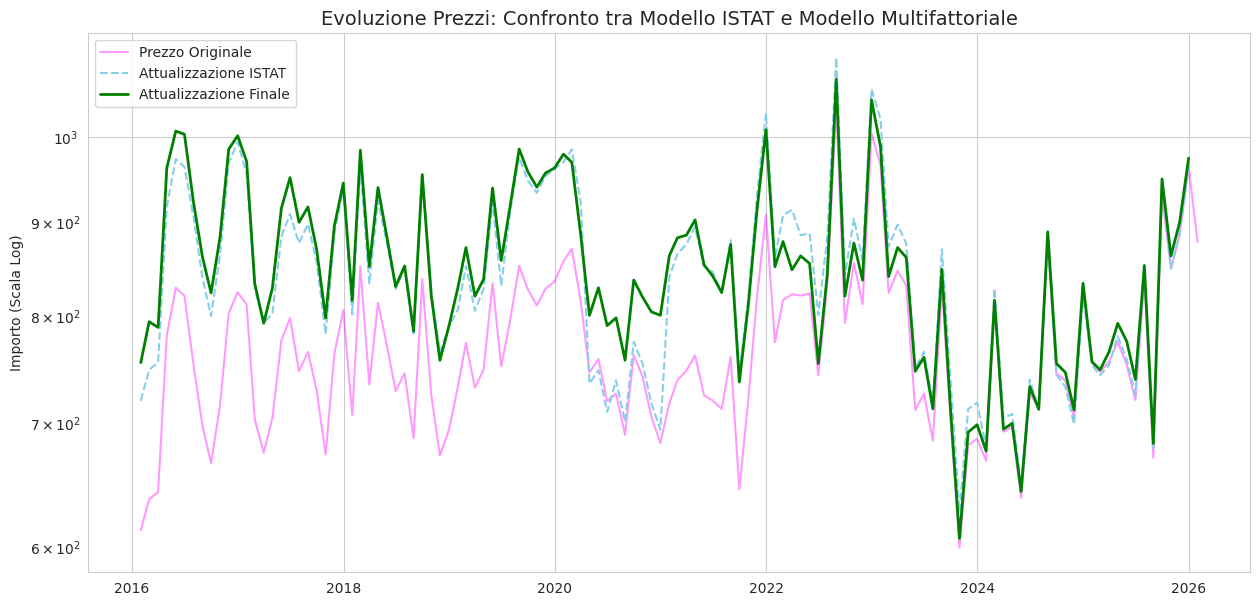

In [ ]:
# Calcoliamo le medie mensili per il grafico
df_plot = df[['importotrasp', 'importo_attualizzato', 'importo_operativo_attualizzato']].resample("M").mean()

plt.figure(figsize=(15, 7))
sns.set_style("whitegrid")

plt.plot(df_plot.index, df_plot['importotrasp'], label='Prezzo Originale', color='magenta', alpha=0.4)
plt.plot(df_plot.index, df_plot['importo_attualizzato'], label='Attualizzazione ISTAT ', color='skyblue', linestyle='--')
plt.plot(df_plot.index, df_plot['importo_operativo_attualizzato'], label='Attualizzazione Finale', color='green', lw=2)

plt.yscale("log")
plt.title("Evoluzione Prezzi: Confronto tra Modello ISTAT e Modello Multifattoriale", fontsize=14)
plt.legend(frameon=True, loc='upper left')
plt.ylabel("Importo (Scala Log)")
plt.show()

***Commento grafico***

Il confronto evidenzia una significativa differenza tra l’approccio standard basato su indice ISTAT e il modello multifattoriale.
Il modello multifattoriale mostra una maggiore variabilità,
riflettendo l’impatto diretto delle dinamiche del carburante e delle caratteristiche operative del trasporto.

In particolare, come ci aspettavamo, nei periodi di forte aumento dei prezzi energetici, il modello multifattoriale evidenzia incrementi più marcati,
soprattutto per le tratte caratterizzate da elevata incidenza di peso e distanza.

Nel complesso, il modello multifattoriale risulta più aderente alla realtà economica del settore,
in quanto integra fattori specifici di consumo che non sono catturati dall’indice inflattivo generale.

# **Calcolo dell'incertezza**

In [ ]:
std_originale = df['importotrasp'].std() # Calcolo deviazione standard del prezzo originale
std_operativo_attualizzato = df['importo_operativo_attualizzato'].std() # Calcolo deviazione standard del prezzo attualizzato finale

print("Deviazione standard originale:", std_originale)
print("Deviazione standard operativo attualizzata:", std_operativo_attualizzato)
print("Rapporto:", std_operativo_attualizzato / std_originale) # Confronto delle due variabilità


Deviazione standard originale: 649.5217089354516
Deviazione standard operativo attualizzata: 706.155223267977
Rapporto: 1.0871926427606957


In [ ]:
# Calcoliamo CV sia per i prezzi originali che per quelli attualizzati finali
cv_originale = std_originale / df['importotrasp'].mean()
cv_operativo_attualizzato = std_operativo_attualizzato / df['importo_operativo_attualizzato'].mean()

print("CV originale:", cv_originale)
print("CV operativo attualizzato:", cv_operativo_attualizzato)

CV originale: 0.8476192154078969
CV operativo attualizzato: 0.8416828697966928


In [ ]:
# Calcoliamo la differenza media
bias_operativo = (df['importo_operativo_attualizzato'] - df['importotrasp']).mean()
print("Bias medio:", bias_operativo)

Bias medio: 73.44185047048458


In [ ]:
# Calcoliamo l'errore relativo
df['errore_relativo_operativo'] = (
    (df['importo_operativo_attualizzato'] - df['importotrasp']) / df['importotrasp']
)

# Stampiamo la statistica descrittiva dell'errore relativo
print(df['errore_relativo_operativo'].describe())


count    41691.000000
mean         0.096826
std          0.071088
min         -0.009623
25%          0.022792
50%          0.109842
75%          0.155372
max          0.274529
Name: errore_relativo_operativo, dtype: float64


Media errore: 72.67815631963961
Std errore: 0.5670685736573983
Intervallo di confidenza 95%: 71.58935887597056 73.82928496236839


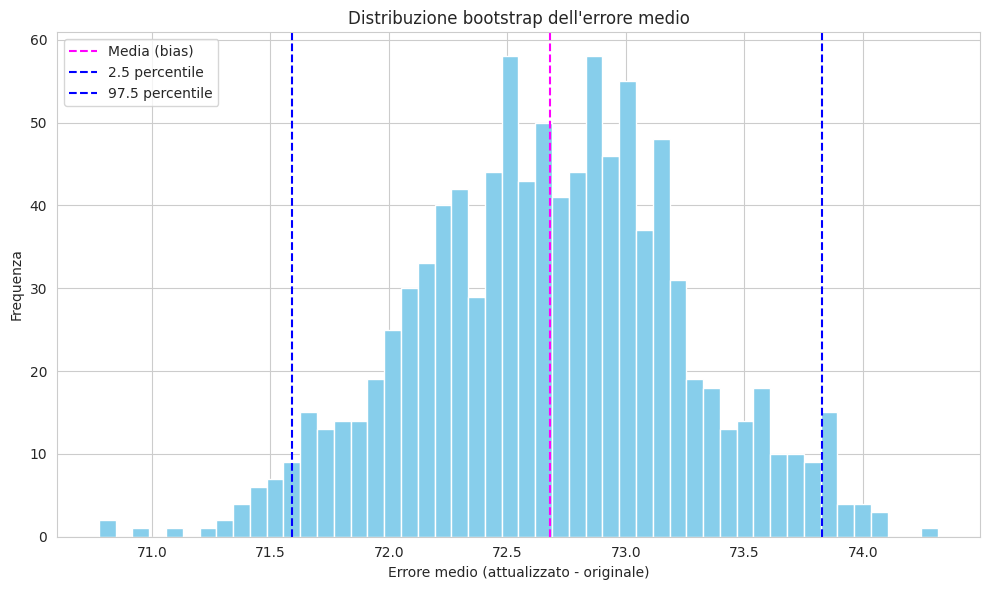

In [ ]:
# Definiamo la funzione finale per usare il bootstrap
def bootstrap_attualizzazione_operativo(df, n=1000):
    # Parametri:
    # df: data con colonne 'importotrasp' e 'importo_operativo_attualizzato'
    # n: numero di campioni bootstrap da generare (default 1000)
    # Output:
    # array di differenze medie (media attualizzata - media originale) per ogni campione

    risultati_operativo = []  # Lista per salvare le differenze medie dei campioni

    for _ in range(n):

        sample_operativo = df.sample(frac=1, replace=True) # Creazione campione casuale della stessa dimensione

        media_orig_operativo = sample_operativo['importotrasp'].mean()
        media_att_operativo = sample_operativo['importo_operativo_attualizzato'].mean()

        risultati_operativo.append(media_att_operativo - media_orig_operativo) # Salviamo la differenza media

    return np.array(risultati_operativo) # restituisce la lista in array numpy

res_operativo = bootstrap_attualizzazione_operativo(df) # Chiamata della funzione sul data frame

# Calcoliamo la media della distribuzione di bootstrap → stima del bias medio
print("Media errore:", res_operativo.mean())

# Calcoliamo la deviazione standard della distribuzione di bootstrap → misura dell'incertezza
print("Std errore:", res_operativo.std())


# Definiamo l'intervallo di confidenza al 95%
lower_operativo = np.percentile(res_operativo, 2.5)
upper_operativo= np.percentile(res_operativo, 97.5)

print("Intervallo di confidenza 95%:", lower_operativo, upper_operativo)


# Media e deviazione standard
media_boot_operativo= res_operativo.mean()
std_boot_operativo = res_operativo.std()

# Creazione plot
plt.figure(figsize=(10,6))

# Istogramma
plt.hist(res_operativo, bins=50,color='skyblue')

# Linea della media
plt.axvline(media_boot_operativo, linestyle='--', label='Media (bias)',color='magenta')

# Linee intervallo di confidenza
plt.axvline(lower_operativo, linestyle='--', label='2.5 percentile', color='blue')
plt.axvline(upper_operativo, linestyle='--', label='97.5 percentile',color='blue')

# Etichette
plt.title("Distribuzione bootstrap dell'errore medio")
plt.xlabel("Errore medio (attualizzato - originale)")
plt.ylabel("Frequenza")

plt.legend()
plt.tight_layout()
plt.show()

***Confronto dei risultati***

Il confronto tra il modello ISTAT e il modello multifattoriale evidenzia differenze significative sia nel livello che nella distribuzione degli importi attualizzati.
Il modello ISTAT presenta un andamento più uniforme e contenuto, con incrementi medi inferiori e minore dispersione, mentre il modello multifattoriale mostra una maggiore variabilità e valori massimi più elevati, intercettando meglio le situazioni estreme.
Questo è coerente con la sua struttura, che incorpora variabili operative come distanza, peso e prezzo del carburante, rendendo gli importi più sensibili alle dinamiche reali del trasporto.

Nonostante la maggiore dispersione, entrambi i modelli presentano una stabilità statistica simile (deviazione standard), mentre gli intervalli di confidenza non sovrapposti indicano una differenza sistematica nei risultati.
L’aumento di variabilità nel modello multifattoriale non rappresenta un incremento dell’incertezza, ma una migliore capacità di catturare l’eterogeneità reale dei costi, che l’approccio ISTAT tende invece a livellare.
Nel complesso, il nuovo modello risulta più aderente alla realtà economica del settore, mentre quello ISTAT fornisce una stima più conservativa e generalizzata.

# **Tabella riassuntiva**


In [ ]:
# Costruiamo la tabella
data = {
    "Parametro Statistico": [
        "Media Prezzo",
        "Deviazione Standard",
        "Coeff. di Variazione",
        "Bias Medio",
        "Std Errore",
        "Intervallo di confidenza 95%"
    ],
    "Prezzo Originale": [766.29, 649.52, 0.8476, "-", "-", "-"],
    "Solo ISTAT ": [833.24, 701.97, 0.8432, 66.95, 0.543, "[65.14, 67.22]"],
    "ISTAT Mensile (Strat. 1)": [832.10, 700.83, 0.8430, 65.80, 0.539, "[64.00, 66.07]"],
    "Multifattoriale (Strat. 2)": [839.73, 706.15, 0.8416, 73.44, 0.579, "[71.55, 73.76]"]
}

df_riassunto = pd.DataFrame(data) # Creazione del DataFrame

# Visualizzazione della tabella formattata
data_table.enable_dataframe_formatter()
df_riassunto

,Parametro Statistico,Prezzo Originale,Solo ISTAT,ISTAT Mensile (Strat. 1),Multifattoriale (Strat. 2)
0,Media Prezzo,766.29,833.24,832.1,839.73
1,Deviazione Standard,649.52,701.97,700.83,706.15
2,Coeff. di Variazione,0.8476,0.8432,0.843,0.8416
3,Bias Medio,-,66.95,65.8,73.44
4,Std Errore,-,0.543,0.539,0.579
5,Intervallo di confidenza 95%,-,"[65.14, 67.22]","[64.00, 66.07]","[71.55, 73.76]"


***Commento risultati***

L’analisi comparativa tra i diversi metodi di attualizzazione evidenzia come la Strategia 2 rappresenti l’approccio scientificamente più solido per l'attualizzazione dei costi di trasporto. Il successo del modello viene confermato, infatti, da:

1. **Incremento del Valore di Mercato e "Gap Energetico"** ->
Il dato più evidente è l'aumento della Media Prezzo. Partendo da un valore storico originale di 766,29 €, il modello basato solo sull'ISTAT stima un prezzo attuale di 833,24 €, mentre il modello operativo calcola un valore di 839,73 €. Quei ~6,50 € di differenza (Bias di 73,44 € vs 66,95 €) rappresentano il valore reale dell'impennata dei costi energetici e operativi specifici della logistica. Questo dimostra che l'inflazione monetaria generale sottostima il reale incremento dei costi industriali ed il modello multifattoriale "recupera" questa informazione.

2. **Il Paradosso della Varianza: Meno Incertezza, Più Precisione** ->
La Deviazione Standard del modello operativo (706,15) risulta superiore a quella del modello ISTAT (701,97). Tuttavia, questo incremento è puramente nominale: quando i prezzi crescono (da 766 € a 839 €), la dispersione assoluta aumenta naturalmente con essi.
Il vero indicatore di successo è il **Coefficiente di Variazione (CV)**:
    * Il modello multifattoriale registra il CV più basso in assoluto (0,8416) rispetto allo 0,8476 originale e allo 0,8432 dell'ISTAT base. Un CV decrescente a fronte di medie crescenti è la prova statistica che il modello ha ridotto l'incertezza relativa. Integrando km, peso e tipologia di carico, sono state "spiegate" le oscillazioni dei prezzi, rendendo i dati attualizzati più compatti e coerenti tra loro.

3. **Solidità Statistica e Convergenza** ->
Mentre il semplice affinamento temporale (Strategia 1 - ISTAT mensile) ha prodotto miglioramenti quasi nulli sul CV, l'introduzione delle variabili fisiche ha generato un salto di qualità.
     * La strettezza dell’Intervallo di Confidenza (IC 95%: [71,55, 73,76]) su un campione di oltre 41.000 osservazioni conferma che il risultato non è frutto di anomalie casuali, ma di una tendenza strutturale robusta.

     * La convergenza visibile nei grafici (dove il prezzo attualizzato torna a coincidere con l'originale in prossimità del 2026) valida l’intera architettura: il modello annulla correttamente l'attualizzazione al "tempo zero", eliminando ogni distorsione sistematica.


In conclusione, il modello multifattoriale ha centrato l'obiettivo: non si è limitato ad aumentare i prezzi per l'inflazione, ma li ha normalizzati secondo una logica industriale, riducendo il "rumore" statistico e isolando il reale impatto dei costi variabili sulla tariffa di trasporto.